In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content

!cp /content/drive/MyDrive/MPNet-master.zip .
!unzip -oq MPNet-master.zip

!cp /content/drive/MyDrive/dataset.zip .
!unzip -oq dataset.zip

%cd /content/MPNet-master/MPNet


Mounted at /content/drive
/content
/content/MPNet-master/MPNet


In [2]:
!sed -i 's/print \"epoch\" + str(epoch)/print(\"epoch\" + str(epoch))/g' AE/CAE.py
!sed -i 's/print \"--average loss:\"/print(\"--average loss:\")/g' AE/CAE.py
!sed -i 's/print avg_loss\/(len(obs)\/args.batch_size)/print(avg_loss\/(len(obs)\/args.batch_size))/g' AE/CAE.py
!sed -i 's/print "--Validation average loss:"/print("--Validation average loss:")/g' AE/CAE.py
!sed -i 's/print avg_loss\/(5000\/args.batch_size)/print(avg_loss\/(5000\/args.batch_size))/g' AE/CAE.py

!grep -n "print " AE/CAE.py


In [3]:
import os
import time
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from AE.CAE import Encoder
from model import MLP


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [5]:
encoder = Encoder().to(device)

encoder.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/cae_encoder.pkl",
        map_location=device
    )
)

encoder.eval()
print("Encoder loaded")


Encoder loaded


In [6]:
pnet = MLP(32, 2).to(device)

pnet.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/mlp_100_4000_PReLU_ae_dd_final.pkl",
        map_location=device
    )
)

pnet.eval()
print("MPNet loaded")


MPNet loaded


In [7]:
DATASET_DIR = "/content/dataset"

obs = np.fromfile(f"{DATASET_DIR}/obs_cloud/obc1.dat")
obs_xy = obs.reshape(-1, 2)

obs_input = torch.from_numpy(obs).float().unsqueeze(0).to(device)

with torch.no_grad():
    obs_code = encoder(obs_input).squeeze(0)

print("obs_code shape:", obs_code.shape)


obs_code shape: torch.Size([28])


In [9]:
print("Has complex_eval_cases:", "complex_eval_cases" in globals())

if "complex_eval_cases" in globals():
    print("num cases:", len(complex_eval_cases))
    c = complex_eval_cases[0]
    print("type:", type(c))
    print("case:", c)

    if isinstance(c, dict):
        print("keys:", c.keys())
    elif isinstance(c, (list, tuple)):
        print("len:", len(c))
        for i, item in enumerate(c):
            print(i, type(item), getattr(item, "shape", None))


Has complex_eval_cases: False


In [11]:
import os

DATASET_DIR = "/content/dataset"

for sub in ["path", "obs_cloud", "obs", "paths"]:
    p = f"{DATASET_DIR}/{sub}"
    print(sub, os.path.exists(p))
    if os.path.exists(p):
        print(os.listdir(p)[:10])


path False
obs_cloud True
['obc14.dat', 'obc0.dat', 'obc19.dat', 'obc16.dat', 'obc7.dat', 'obc9.dat', 'obc3.dat', 'obc11.dat', 'obc17.dat', 'obc1.dat']
obs False
paths False


In [12]:
import os

for root, dirs, files in os.walk("/content"):
    dat_files = [f for f in files if f.endswith(".dat")]
    if dat_files:
        print(root)
        print(dat_files[:10])
        print("num dat:", len(dat_files))
        print()


/content/MPNet-master/data_generation
['obs.dat', 'obs_perm2.dat']
num dat: 2

/content/dataset
['obs.dat', 'obs_perm2.dat']
num dat: 2

/content/dataset/e7
['path164.dat', 'path148.dat', 'path179.dat', 'path144.dat', 'path215.dat', 'path118.dat', 'path231.dat', 'path121.dat', 'path50.dat', 'path281.dat']
num dat: 300

/content/dataset/e2
['path164.dat', 'path148.dat', 'path179.dat', 'path144.dat', 'path215.dat', 'path118.dat', 'path231.dat', 'path121.dat', 'path50.dat', 'path281.dat']
num dat: 300

/content/dataset/e9
['path164.dat', 'path148.dat', 'path179.dat', 'path144.dat', 'path215.dat', 'path118.dat', 'path231.dat', 'path121.dat', 'path50.dat', 'path281.dat']
num dat: 300

/content/dataset/e6
['path164.dat', 'path148.dat', 'path179.dat', 'path144.dat', 'path215.dat', 'path118.dat', 'path231.dat', 'path121.dat', 'path50.dat', 'path281.dat']
num dat: 300

/content/dataset/e10
['path164.dat', 'path148.dat', 'path179.dat', 'path144.dat', 'path215.dat', 'path118.dat', 'path231.dat', 

In [13]:
import os

keywords = ["path", "test", "train", "start", "goal", "sg"]

for root, dirs, files in os.walk("/content"):
    for f in files:
        name = f.lower()
        if f.endswith(".dat") and any(k in root.lower() or k in name for k in keywords):
            full = os.path.join(root, f)
            print(full, "size:", os.path.getsize(full))


/content/dataset/e7/path164.dat size: 304
/content/dataset/e7/path148.dat size: 336
/content/dataset/e7/path179.dat size: 256
/content/dataset/e7/path144.dat size: 288
/content/dataset/e7/path215.dat size: 400
/content/dataset/e7/path118.dat size: 368
/content/dataset/e7/path231.dat size: 464
/content/dataset/e7/path121.dat size: 256
/content/dataset/e7/path50.dat size: 256
/content/dataset/e7/path281.dat size: 384
/content/dataset/e7/path124.dat size: 432
/content/dataset/e7/path141.dat size: 320
/content/dataset/e7/path90.dat size: 272
/content/dataset/e7/path42.dat size: 448
/content/dataset/e7/path10.dat size: 416
/content/dataset/e7/path224.dat size: 384
/content/dataset/e7/path115.dat size: 320
/content/dataset/e7/path223.dat size: 352
/content/dataset/e7/path19.dat size: 368
/content/dataset/e7/path81.dat size: 352
/content/dataset/e7/path182.dat size: 384
/content/dataset/e7/path152.dat size: 288
/content/dataset/e7/path226.dat size: 272
/content/dataset/e7/path102.dat size: 33

In [14]:
!find /content/drive/MyDrive -iname "*path*" -o -iname "*test*" -o -iname "*dataset*"


/content/drive/MyDrive/dataset.zip


In [15]:
import zipfile

zip_path = "/content/drive/MyDrive/dataset.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    names = z.namelist()
    print("Total files:", len(names))

    print("\nFirst 80 files:")
    for n in names[:80]:
        print(n)

    print("\nPath-like files:")
    hits = [
        n for n in names
        if any(k in n.lower() for k in ["path", "paths", "start", "goal", "sg", "test", "train"])
    ]
    print("num hits:", len(hits))
    for n in hits[:100]:
        print(n)


Total files: 6044

First 80 files:
dataset/
dataset/e19/
dataset/e19/path294.dat
dataset/e19/path178.dat
dataset/e19/path83.dat
dataset/e19/path261.dat
dataset/e19/path185.dat
dataset/e19/path282.dat
dataset/e19/path177.dat
dataset/e19/path1.dat
dataset/e19/path277.dat
dataset/e19/path92.dat
dataset/e19/path226.dat
dataset/e19/path256.dat
dataset/e19/path5.dat
dataset/e19/path258.dat
dataset/e19/path108.dat
dataset/e19/path195.dat
dataset/e19/path222.dat
dataset/e19/path210.dat
dataset/e19/path93.dat
dataset/e19/path175.dat
dataset/e19/path207.dat
dataset/e19/path297.dat
dataset/e19/path115.dat
dataset/e19/path121.dat
dataset/e19/path196.dat
dataset/e19/path61.dat
dataset/e19/path113.dat
dataset/e19/path24.dat
dataset/e19/path259.dat
dataset/e19/path135.dat
dataset/e19/path199.dat
dataset/e19/path104.dat
dataset/e19/path187.dat
dataset/e19/path90.dat
dataset/e19/path2.dat
dataset/e19/path188.dat
dataset/e19/path0.dat
dataset/e19/path148.dat
dataset/e19/path109.dat
dataset/e19/path257.d

In [16]:
zip_path = "/content/drive/MyDrive/MPNet-master.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    names = z.namelist()
    print("Total files:", len(names))

    hits = [
        n for n in names
        if any(k in n.lower() for k in ["path", "paths", "start", "goal", "sg", "test", "train", ".dat"])
    ]
    print("num hits:", len(hits))
    for n in hits[:120]:
        print(n)


Total files: 118
num hits: 3
MPNet-master/MPNet/train.py
MPNet-master/data_generation/obs.dat
MPNet-master/data_generation/obs_perm2.dat


In [17]:
import os
import numpy as np

DATASET_DIR = "/content/dataset"

for env_id in [1, 6, 12, 14, 19]:
    p = f"{DATASET_DIR}/e{env_id}/path0.dat"
    if os.path.exists(p):
        arr = np.fromfile(p)
        print("env", env_id, "size:", arr.size, "points:", arr.size // 2, "first values:", arr[:6])


env 1 size: 36 points: 18 first values: [0.54168682 0.64640174 0.51538951 0.59764683 0.4890922  0.54889193]
env 6 size: 40 points: 20 first values: [0.62788329 0.36949235 0.62803403 0.3547767  0.62818478 0.34006104]
env 12 size: 46 points: 23 first values: [0.8302519  0.16249366 0.79802862 0.17075536 0.76580533 0.17901706]
env 14 size: 42 points: 21 first values: [0.78757907 0.72650467 0.79364235 0.71734344 0.79970563 0.7081822 ]
env 19 size: 48 points: 24 first values: [0.81325004 0.97431515 0.78512814 0.93463201 0.75700625 0.89494887]


In [18]:
import os
import re
import numpy as np
import torch

DATASET_DIR = "/content/dataset"

GOAL_THRESHOLD = 0.10
COLLISION_THRESHOLD = 0.03


def load_obs_xy(env_id):
    obs_file = f"{DATASET_DIR}/obs_cloud/obc{env_id}.dat"
    obs = np.fromfile(obs_file)
    return obs.reshape(-1, 2).astype(np.float32)


def load_expert_path(env_id, case_id):
    path_file = f"{DATASET_DIR}/e{env_id}/path{case_id}.dat"
    path = np.fromfile(path_file)
    return path.reshape(-1, 2).astype(np.float32)


def sorted_case_ids(env_id):
    folder = f"{DATASET_DIR}/e{env_id}"
    files = [f for f in os.listdir(folder) if re.match(r"path\d+\.dat$", f)]
    ids = sorted(int(re.findall(r"\d+", f)[0]) for f in files)
    return ids


def get_obs_code(obs_xy):
    obs_flat = obs_xy.reshape(-1)
    obs_input = torch.from_numpy(obs_flat).float().unsqueeze(0).to(device)
    with torch.no_grad():
        return encoder(obs_input).squeeze(0)


def path_length_np(path):
    path = np.asarray(path, dtype=np.float32)
    if len(path) < 2:
        return 0.0
    return float(np.sum(np.linalg.norm(path[1:] - path[:-1], axis=1)))


def line_intersects_obstacles(start, goal, obs_xy, threshold=0.03, samples=60):
    start = np.asarray(start, dtype=np.float32)
    goal = np.asarray(goal, dtype=np.float32)

    for i in range(samples + 1):
        t = i / samples
        p = (1.0 - t) * start + t * goal
        d = np.linalg.norm(obs_xy - p, axis=1)
        if np.min(d) < threshold:
            return True

    return False


def build_complex_eval_cases(max_cases=100, env_ids=range(1, 15)):
    cases = []

    for env_id in env_ids:
        obs_xy = load_obs_xy(env_id)
        obs_code = get_obs_code(obs_xy)

        for case_id in sorted_case_ids(env_id):
            expert_path = load_expert_path(env_id, case_id)

            if len(expert_path) < 2:
                continue

            start = expert_path[0]
            goal = expert_path[-1]

            straight_len = float(np.linalg.norm(goal - start))
            expert_len = path_length_np(expert_path)

            if straight_len < 1e-6:
                continue

            # Challenging subset:
            # 1. straight-line path intersects obstacle cloud
            # 2. expert path requires a visible detour
            straight_collision = line_intersects_obstacles(
                start, goal, obs_xy,
                threshold=COLLISION_THRESHOLD,
                samples=60
            )

            detour_required = expert_len > 1.15 * straight_len

            if straight_collision and detour_required:
                cases.append({
                    "env_id": env_id,
                    "case_id": case_id,
                    "start": start,
                    "goal": goal,
                    "obs_xy": obs_xy,
                    "obs_code": obs_code,
                    "expert_path": expert_path,
                    "straight_len": straight_len,
                    "expert_len": expert_len,
                })

                if len(cases) >= max_cases:
                    return cases

    return cases


complex_eval_cases = build_complex_eval_cases(max_cases=100)

print("complex_eval_cases:", len(complex_eval_cases))

if len(complex_eval_cases) > 0:
    c = complex_eval_cases[0]
    print("first env/case:", c["env_id"], c["case_id"])
    print("start:", c["start"])
    print("goal:", c["goal"])
    print("expert path shape:", c["expert_path"].shape)
    print("straight len:", c["straight_len"])
    print("expert len:", c["expert_len"])


complex_eval_cases: 100
first env/case: 1 0
start: [0.54168683 0.64640176]
goal: [0.54536283 0.05120635]
expert path shape: (18, 2)
straight len: 0.5952067375183105
expert len: 0.8415063619613647


In [19]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

GOAL_THRESHOLD = 0.10
COLLISION_THRESHOLD = 0.03


def path_length_np(path):
    path = np.asarray(path, dtype=np.float32)
    if len(path) < 2:
        return 0.0
    return float(np.sum(np.linalg.norm(path[1:] - path[:-1], axis=1)))


def path_in_collision(path, obs_xy, threshold=0.03, samples_per_segment=20):
    path = np.asarray(path, dtype=np.float32)
    obs_xy = np.asarray(obs_xy, dtype=np.float32).reshape(-1, 2)

    if len(path) < 2:
        return False

    for i in range(len(path) - 1):
        a = path[i]
        b = path[i + 1]

        for s in range(samples_per_segment + 1):
            t = s / samples_per_segment
            p = (1.0 - t) * a + t * b

            d = np.linalg.norm(obs_xy - p, axis=1)
            if np.min(d) < threshold:
                return True

    return False


def evaluate_path(path, goal, obs_xy, expert_path=None):
    path = np.asarray(path, dtype=np.float32)
    goal = np.asarray(goal, dtype=np.float32)

    final_dist = float(np.linalg.norm(path[-1] - goal))
    collision = path_in_collision(
        path,
        obs_xy,
        threshold=COLLISION_THRESHOLD,
        samples_per_segment=20
    )

    length = path_length_np(path)
    success = (final_dist <= GOAL_THRESHOLD) and (not collision)

    ratio = np.nan
    if expert_path is not None:
        expert_len = path_length_np(expert_path)
        if expert_len > 1e-8:
            ratio = length / expert_len

    return {
        "success": success,
        "collision": collision,
        "final_dist": final_dist,
        "path_length": length,
        "ratio": ratio,
    }


def generate_goal_bias_path(start, goal, obs_code, alpha=0.0, max_steps=150):
    current = torch.from_numpy(np.asarray(start, dtype=np.float32)).float().to(device)
    goal_t = torch.from_numpy(np.asarray(goal, dtype=np.float32)).float().to(device)

    if not isinstance(obs_code, torch.Tensor):
        obs_code = torch.from_numpy(np.asarray(obs_code, dtype=np.float32)).float().to(device)
    else:
        obs_code = obs_code.float().to(device)

    obs_code = obs_code.view(-1)

    path = [current.detach().cpu().numpy()]

    with torch.no_grad():
        for _ in range(max_steps):
            inp = torch.cat([obs_code, goal_t, current]).unsqueeze(0)

            pred = pnet(inp).squeeze(0)

            # Fixed-alpha goal bias.
            # alpha = 0.0 means pure MPNet prediction.
            # Larger alpha pulls each predicted state toward the goal.
            next_state = (1.0 - alpha) * pred + alpha * goal_t

            path.append(next_state.detach().cpu().numpy())
            current = next_state

            if torch.norm(current - goal_t).item() <= GOAL_THRESHOLD:
                break

    return np.asarray(path, dtype=np.float32)


def evaluate_alpha_on_cases(cases, alpha_values):
    rows = []

    for alpha in alpha_values:
        metrics_all = []

        for case in cases:
            start = case["start"]
            goal = case["goal"]
            obs_xy = case["obs_xy"]
            obs_code = case["obs_code"]
            expert_path = case["expert_path"]

            t0 = time.time()
            path = generate_goal_bias_path(
                start=start,
                goal=goal,
                obs_code=obs_code,
                alpha=alpha,
                max_steps=150
            )
            elapsed = time.time() - t0

            metrics = evaluate_path(path, goal, obs_xy, expert_path)
            metrics["time"] = elapsed
            metrics_all.append(metrics)

        row = {
            "alpha": alpha,
            "success_rate": 100.0 * np.mean([m["success"] for m in metrics_all]),
            "collision_rate": 100.0 * np.mean([m["collision"] for m in metrics_all]),
            "avg_time": float(np.mean([m["time"] for m in metrics_all])),
            "avg_path_length": float(np.mean([m["path_length"] for m in metrics_all])),
            "avg_final_dist": float(np.mean([m["final_dist"] for m in metrics_all])),
            "avg_ratio": float(np.nanmean([m["ratio"] for m in metrics_all])),
        }

        rows.append(row)
        print(row)

    return pd.DataFrame(rows)


alpha_values = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]

alpha_df = evaluate_alpha_on_cases(complex_eval_cases[:100], alpha_values)
display(alpha_df)


{'alpha': 0.0, 'success_rate': np.float64(0.0), 'collision_rate': np.float64(100.0), 'avg_time': 0.009727969169616699, 'avg_path_length': 0.5641315966844559, 'avg_final_dist': 0.06028152862563729, 'avg_ratio': 0.5922998739369737}
{'alpha': 0.05, 'success_rate': np.float64(0.0), 'collision_rate': np.float64(100.0), 'avg_time': 0.0032896685600280764, 'avg_path_length': 0.5646474231779576, 'avg_final_dist': 0.058780953753739595, 'avg_ratio': 0.5928874258625707}
{'alpha': 0.1, 'success_rate': np.float64(0.0), 'collision_rate': np.float64(100.0), 'avg_time': 0.0033333897590637207, 'avg_path_length': 0.5668339636921883, 'avg_final_dist': 0.055943079376593235, 'avg_ratio': 0.5952617251062114}
{'alpha': 0.2, 'success_rate': np.float64(0.0), 'collision_rate': np.float64(100.0), 'avg_time': 0.001398446559906006, 'avg_path_length': 0.570561405569315, 'avg_final_dist': 0.05083337635733187, 'avg_ratio': 0.5993449117186804}
{'alpha': 0.3, 'success_rate': np.float64(0.0), 'collision_rate': np.float64

,alpha,success_rate,collision_rate,avg_time,avg_path_length,avg_final_dist,avg_ratio
0,0.00,0.0,100.0,0.009728,0.564132,0.060282,0.592300
1,0.05,0.0,100.0,0.003290,0.564647,0.058781,0.592887
2,0.10,0.0,100.0,0.003333,0.566834,0.055943,0.595262
3,0.20,0.0,100.0,0.001398,0.570561,0.050833,0.599345
4,0.30,0.0,100.0,0.001322,0.575580,0.044618,0.604608
5,0.50,0.0,100.0,0.001328,0.586021,0.031870,0.615579


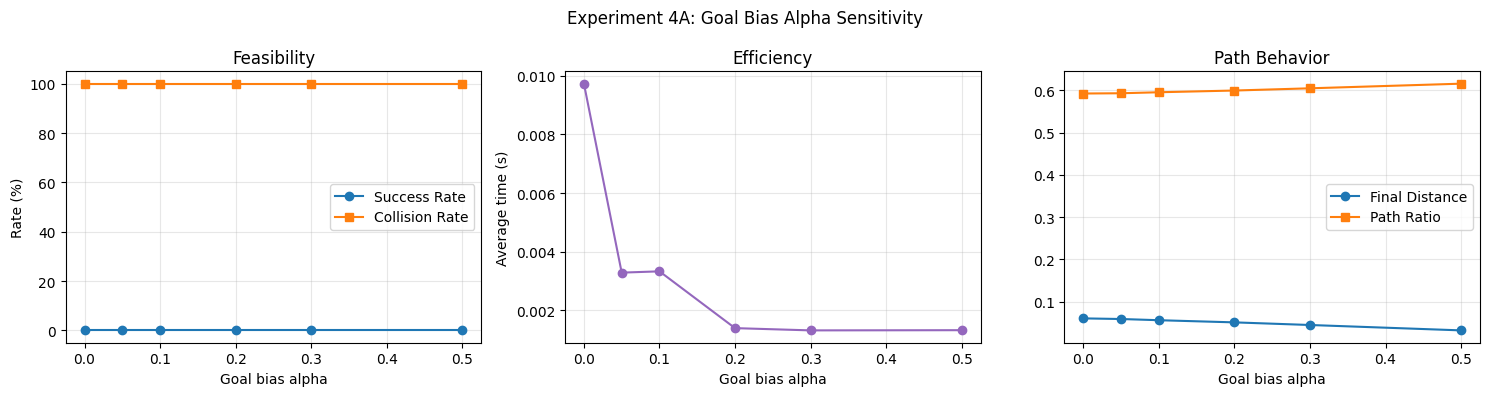

Saved alpha sensitivity results


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(alpha_df["alpha"], alpha_df["success_rate"], marker="o", label="Success Rate")
axes[0].plot(alpha_df["alpha"], alpha_df["collision_rate"], marker="s", label="Collision Rate")
axes[0].set_xlabel("Goal bias alpha")
axes[0].set_ylabel("Rate (%)")
axes[0].set_title("Feasibility")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(alpha_df["alpha"], alpha_df["avg_time"], marker="o", color="tab:purple")
axes[1].set_xlabel("Goal bias alpha")
axes[1].set_ylabel("Average time (s)")
axes[1].set_title("Efficiency")
axes[1].grid(True, alpha=0.3)

axes[2].plot(alpha_df["alpha"], alpha_df["avg_final_dist"], marker="o", label="Final Distance")
axes[2].plot(alpha_df["alpha"], alpha_df["avg_ratio"], marker="s", label="Path Ratio")
axes[2].set_xlabel("Goal bias alpha")
axes[2].set_title("Path Behavior")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.suptitle("Experiment 4A: Goal Bias Alpha Sensitivity")
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/experiment4_alpha_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

alpha_df.to_csv("/content/drive/MyDrive/experiment4_alpha_sensitivity.csv", index=False)
print("Saved alpha sensitivity results")


In [21]:
def build_overall_eval_cases(cases_per_env=50, env_ids=range(1, 15)):
    cases = []

    for env_id in env_ids:
        obs_xy = load_obs_xy(env_id)
        obs_code = get_obs_code(obs_xy)

        ids = sorted_case_ids(env_id)[:cases_per_env]

        for case_id in ids:
            expert_path = load_expert_path(env_id, case_id)

            if len(expert_path) < 2:
                continue

            cases.append({
                "env_id": env_id,
                "case_id": case_id,
                "start": expert_path[0],
                "goal": expert_path[-1],
                "obs_xy": obs_xy,
                "obs_code": obs_code,
                "expert_path": expert_path,
            })

    return cases


overall_eval_cases = build_overall_eval_cases(cases_per_env=50)

print("overall_eval_cases:", len(overall_eval_cases))
print(overall_eval_cases[0]["env_id"], overall_eval_cases[0]["case_id"])


overall_eval_cases: 700
1 0


In [22]:
alpha_df = evaluate_alpha_on_cases(overall_eval_cases, alpha_values)
display(alpha_df)


{'alpha': 0.0, 'success_rate': np.float64(41.0), 'collision_rate': np.float64(56.85714285714286), 'avg_time': 0.01066701854978289, 'avg_path_length': 0.4757798293126481, 'avg_final_dist': 0.05989128019710604, 'avg_ratio': 0.7919024625345089}
{'alpha': 0.05, 'success_rate': np.float64(41.714285714285715), 'collision_rate': np.float64(56.42857142857143), 'avg_time': 0.009418513774871826, 'avg_path_length': 0.47725554016019617, 'avg_final_dist': 0.05738136821243513, 'avg_ratio': 0.79357345810256}
{'alpha': 0.1, 'success_rate': np.float64(42.42857142857142), 'collision_rate': np.float64(56.42857142857143), 'avg_time': 0.006544440473828997, 'avg_path_length': 0.47902096659477267, 'avg_final_dist': 0.05472137162844384, 'avg_ratio': 0.7959089703758179}
{'alpha': 0.2, 'success_rate': np.float64(43.42857142857143), 'collision_rate': np.float64(56.00000000000001), 'avg_time': 0.0040493576867239815, 'avg_path_length': 0.4824920721431928, 'avg_final_dist': 0.04948094552915011, 'avg_ratio': 0.80081

,alpha,success_rate,collision_rate,avg_time,avg_path_length,avg_final_dist,avg_ratio
0,0.00,41.000000,56.857143,0.010667,0.475780,0.059891,0.791902
1,0.05,41.714286,56.428571,0.009419,0.477256,0.057381,0.793573
2,0.10,42.428571,56.428571,0.006544,0.479021,0.054721,0.795909
3,0.20,43.428571,56.000000,0.004049,0.482492,0.049481,0.800817
4,0.30,44.000000,56.000000,0.001653,0.486664,0.043710,0.806687
5,0.50,44.857143,55.142857,0.001382,0.496121,0.031354,0.820288


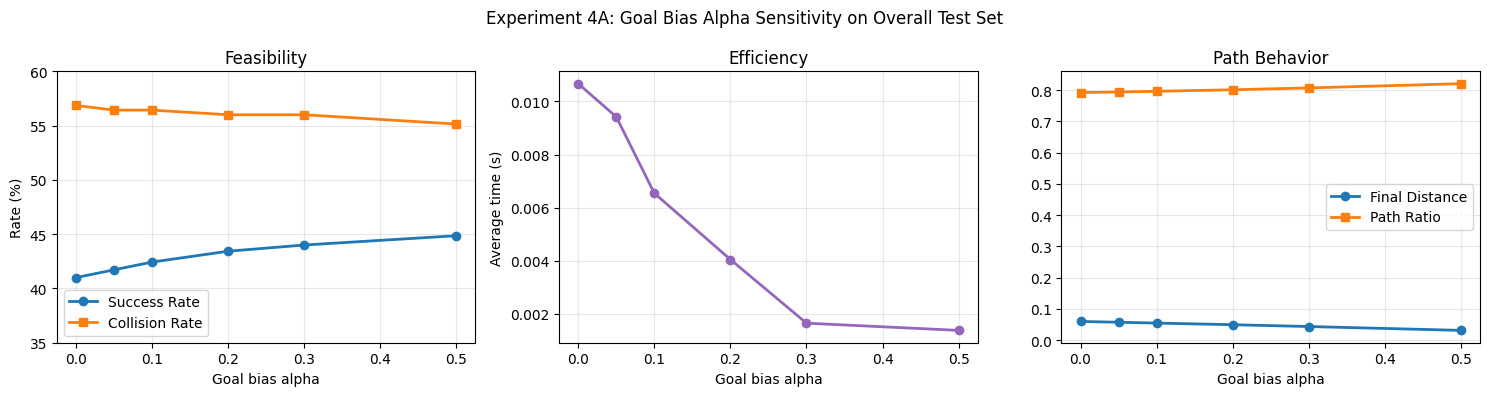

Saved: /content/drive/MyDrive/experiment4_alpha_sensitivity_overall.png


In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Feasibility
axes[0].plot(
    alpha_df["alpha"],
    alpha_df["success_rate"],
    marker="o",
    linewidth=2,
    label="Success Rate"
)
axes[0].plot(
    alpha_df["alpha"],
    alpha_df["collision_rate"],
    marker="s",
    linewidth=2,
    label="Collision Rate"
)
axes[0].set_xlabel("Goal bias alpha")
axes[0].set_ylabel("Rate (%)")
axes[0].set_title("Feasibility")
axes[0].set_ylim(35, 60)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Efficiency
axes[1].plot(
    alpha_df["alpha"],
    alpha_df["avg_time"],
    marker="o",
    linewidth=2,
    color="tab:purple"
)
axes[1].set_xlabel("Goal bias alpha")
axes[1].set_ylabel("Average time (s)")
axes[1].set_title("Efficiency")
axes[1].grid(True, alpha=0.3)

# Path behavior
axes[2].plot(
    alpha_df["alpha"],
    alpha_df["avg_final_dist"],
    marker="o",
    linewidth=2,
    label="Final Distance"
)
axes[2].plot(
    alpha_df["alpha"],
    alpha_df["avg_ratio"],
    marker="s",
    linewidth=2,
    label="Path Ratio"
)
axes[2].set_xlabel("Goal bias alpha")
axes[2].set_title("Path Behavior")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.suptitle("Experiment 4A: Goal Bias Alpha Sensitivity on Overall Test Set")
plt.tight_layout()

save_path = "/content/drive/MyDrive/experiment4_alpha_sensitivity_overall.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

alpha_df.to_csv(
    "/content/drive/MyDrive/experiment4_alpha_sensitivity_overall.csv",
    index=False
)

print("Saved:", save_path)


In [27]:
hybrid_cases = complex_eval_cases[:100]
print("Hybrid sensitivity cases:", len(hybrid_cases))


Hybrid sensitivity cases: 100


In [28]:
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def steer(from_state, to_state, step_size=0.04):
    from_state = np.asarray(from_state, dtype=np.float32)
    to_state = np.asarray(to_state, dtype=np.float32)

    direction = to_state - from_state
    dist = np.linalg.norm(direction)

    if dist <= step_size:
        return to_state

    return from_state + step_size * direction / (dist + 1e-8)


def edge_in_collision(a, b, obs_xy, threshold=0.03, samples=20):
    path = np.asarray([a, b], dtype=np.float32)
    return path_in_collision(
        path,
        obs_xy,
        threshold=threshold,
        samples_per_segment=samples
    )


def rrt_repair(start, goal, obs_xy, max_iter=6000, step_size=0.04, goal_sample_rate=0.20):
    start = np.asarray(start, dtype=np.float32)
    goal = np.asarray(goal, dtype=np.float32)

    nodes = [start]
    parents = [-1]

    for _ in range(max_iter):
        if random.random() < goal_sample_rate:
            sample = goal
        else:
            sample = np.random.uniform(0.0, 1.0, size=2).astype(np.float32)

        nearest_idx = int(np.argmin([np.linalg.norm(n - sample) for n in nodes]))
        nearest = nodes[nearest_idx]

        new_node = steer(nearest, sample, step_size=step_size)

        if edge_in_collision(nearest, new_node, obs_xy):
            continue

        nodes.append(new_node)
        parents.append(nearest_idx)

        if np.linalg.norm(new_node - goal) <= GOAL_THRESHOLD:
            if not edge_in_collision(new_node, goal, obs_xy):
                nodes.append(goal)
                parents.append(len(nodes) - 2)

                path = []
                idx = len(nodes) - 1

                while idx != -1:
                    path.append(nodes[idx])
                    idx = parents[idx]

                return np.asarray(path[::-1], dtype=np.float32), True

    return np.asarray([start], dtype=np.float32), False


def first_collision_prefix(path, obs_xy):
    path = np.asarray(path, dtype=np.float32)

    if len(path) <= 1:
        return path

    safe = [path[0]]

    for i in range(1, len(path)):
        if edge_in_collision(path[i - 1], path[i], obs_xy):
            break
        safe.append(path[i])

    return np.asarray(safe, dtype=np.float32)


def generate_hybrid_mpnet_path_v3(start, goal, obs_code, obs_xy, max_iter=6000):
    coarse_path = generate_goal_bias_path(
        start=start,
        goal=goal,
        obs_code=obs_code,
        alpha=0.0,
        max_steps=150
    )

    safe_prefix = first_collision_prefix(coarse_path, obs_xy)
    repair_start = safe_prefix[-1]

    repair_path, repair_success = rrt_repair(
        start=repair_start,
        goal=goal,
        obs_xy=obs_xy,
        max_iter=max_iter,
        step_size=0.04,
        goal_sample_rate=0.20
    )

    if repair_success and len(repair_path) > 1:
        full_path = np.vstack([safe_prefix, repair_path[1:]])
    else:
        full_path = safe_prefix

    info = {
        "repair_success": repair_success,
        "safe_prefix_len": len(safe_prefix),
    }

    return full_path, info


def evaluate_hybrid_max_iter_on_cases(cases, max_iter_values):
    rows = []

    for max_iter in max_iter_values:
        metrics_all = []

        for case in cases:
            start = case["start"]
            goal = case["goal"]
            obs_xy = case["obs_xy"]
            obs_code = case["obs_code"]
            expert_path = case["expert_path"]

            t0 = time.time()

            path, info = generate_hybrid_mpnet_path_v3(
                start=start,
                goal=goal,
                obs_code=obs_code,
                obs_xy=obs_xy,
                max_iter=max_iter
            )

            elapsed = time.time() - t0

            metrics = evaluate_path(path, goal, obs_xy, expert_path)
            metrics["time"] = elapsed
            metrics["repair_success"] = info["repair_success"]
            metrics["safe_prefix_len"] = info["safe_prefix_len"]

            metrics_all.append(metrics)

        row = {
            "max_iter": max_iter,
            "success_rate": 100.0 * np.mean([m["success"] for m in metrics_all]),
            "collision_rate": 100.0 * np.mean([m["collision"] for m in metrics_all]),
            "avg_time": float(np.mean([m["time"] for m in metrics_all])),
            "avg_path_length": float(np.mean([m["path_length"] for m in metrics_all])),
            "repair_success_rate": 100.0 * np.mean([m["repair_success"] for m in metrics_all]),
            "avg_safe_prefix_len": float(np.mean([m["safe_prefix_len"] for m in metrics_all])),
        }

        rows.append(row)
        print(row)

    return pd.DataFrame(rows)


In [30]:
def generate_hybrid_mpnet_path_v3(start, goal, obs_code, obs_xy, max_iter=6000):
    coarse_path = generate_goal_bias_path(
        start=start,
        goal=goal,
        obs_code=obs_code,
        alpha=0.0,
        max_steps=150
    )

    safe_prefix = first_collision_prefix(coarse_path, obs_xy)
    repair_start = safe_prefix[-1]

    repair_path, repair_success = rrt_repair(
        start=repair_start,
        goal=goal,
        obs_xy=obs_xy,
        max_iter=max_iter,
        step_size=0.04,
        goal_sample_rate=0.20
    )

    if repair_success and len(repair_path) > 1:
        full_path = np.vstack([safe_prefix, repair_path[1:]])
    else:
        # Important: keep the original MPNet path when repair fails,
        # so failed hybrid cases still reflect the collision behavior.
        full_path = coarse_path

    info = {
        "repair_success": repair_success,
        "safe_prefix_len": len(safe_prefix),
    }

    return full_path, info


In [31]:
hybrid_iter_df_test = evaluate_hybrid_max_iter_on_cases(
    hybrid_cases[:10],
    [3000, 6000]
)

display(hybrid_iter_df_test)


{'max_iter': 3000, 'success_rate': np.float64(80.0), 'collision_rate': np.float64(20.0), 'avg_time': 1.631970429420471, 'avg_path_length': 0.8100229918956756, 'repair_success_rate': np.float64(80.0), 'avg_safe_prefix_len': 1.0}
{'max_iter': 6000, 'success_rate': np.float64(80.0), 'collision_rate': np.float64(20.0), 'avg_time': 5.293007230758667, 'avg_path_length': 0.8036165654659271, 'repair_success_rate': np.float64(80.0), 'avg_safe_prefix_len': 1.0}


,max_iter,success_rate,collision_rate,avg_time,avg_path_length,repair_success_rate,avg_safe_prefix_len
0,3000,80.0,20.0,1.631970,0.810023,80.0,1.0
1,6000,80.0,20.0,5.293007,0.803617,80.0,1.0


In [32]:
max_iter_values = [300, 600, 1000, 3000]

hybrid_iter_df = evaluate_hybrid_max_iter_on_cases(
    hybrid_cases,
    max_iter_values
)

display(hybrid_iter_df)


{'max_iter': 300, 'success_rate': np.float64(74.0), 'collision_rate': np.float64(26.0), 'avg_time': 0.15656567096710206, 'avg_path_length': 0.7938686309754849, 'repair_success_rate': np.float64(74.0), 'avg_safe_prefix_len': 1.0}
{'max_iter': 600, 'success_rate': np.float64(76.0), 'collision_rate': np.float64(24.0), 'avg_time': 0.22766112565994262, 'avg_path_length': 0.8190236262977123, 'repair_success_rate': np.float64(76.0), 'avg_safe_prefix_len': 1.0}
{'max_iter': 1000, 'success_rate': np.float64(76.0), 'collision_rate': np.float64(24.0), 'avg_time': 0.36386578798294067, 'avg_path_length': 0.8154633398354053, 'repair_success_rate': np.float64(76.0), 'avg_safe_prefix_len': 1.0}
{'max_iter': 3000, 'success_rate': np.float64(76.0), 'collision_rate': np.float64(24.0), 'avg_time': 1.360016140937805, 'avg_path_length': 0.8045162804424763, 'repair_success_rate': np.float64(76.0), 'avg_safe_prefix_len': 1.0}


,max_iter,success_rate,collision_rate,avg_time,avg_path_length,repair_success_rate,avg_safe_prefix_len
0,300,74.0,26.0,0.156566,0.793869,74.0,1.0
1,600,76.0,24.0,0.227661,0.819024,76.0,1.0
2,1000,76.0,24.0,0.363866,0.815463,76.0,1.0
3,3000,76.0,24.0,1.360016,0.804516,76.0,1.0


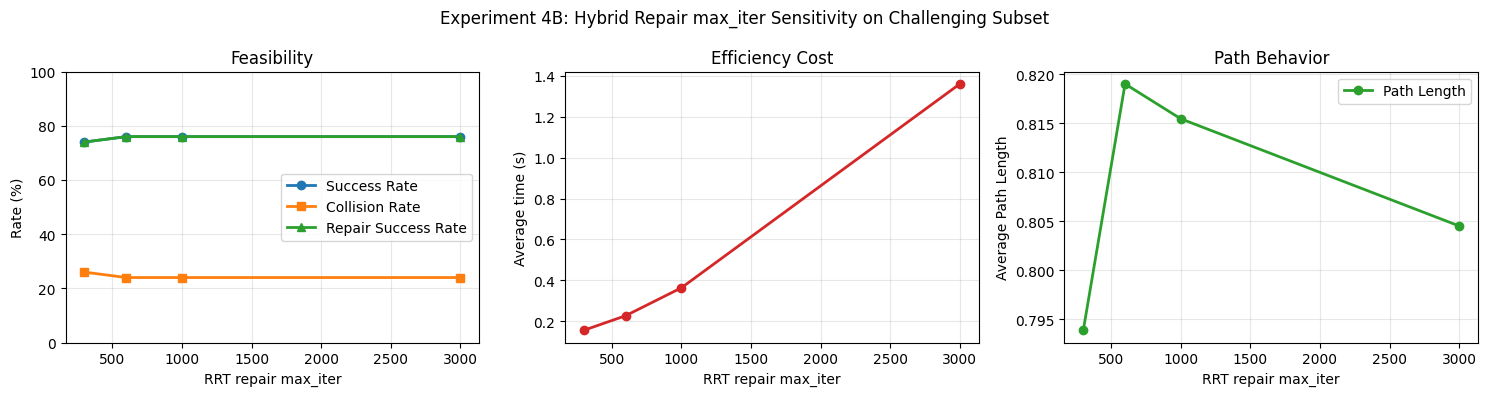

Saved: /content/drive/MyDrive/experiment4_hybrid_max_iter_sensitivity.png


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Feasibility
axes[0].plot(
    hybrid_iter_df["max_iter"],
    hybrid_iter_df["success_rate"],
    marker="o",
    linewidth=2,
    label="Success Rate"
)
axes[0].plot(
    hybrid_iter_df["max_iter"],
    hybrid_iter_df["collision_rate"],
    marker="s",
    linewidth=2,
    label="Collision Rate"
)
axes[0].plot(
    hybrid_iter_df["max_iter"],
    hybrid_iter_df["repair_success_rate"],
    marker="^",
    linewidth=2,
    label="Repair Success Rate"
)
axes[0].set_xlabel("RRT repair max_iter")
axes[0].set_ylabel("Rate (%)")
axes[0].set_title("Feasibility")
axes[0].set_ylim(0, 100)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Efficiency
axes[1].plot(
    hybrid_iter_df["max_iter"],
    hybrid_iter_df["avg_time"],
    marker="o",
    linewidth=2,
    color="tab:red"
)
axes[1].set_xlabel("RRT repair max_iter")
axes[1].set_ylabel("Average time (s)")
axes[1].set_title("Efficiency Cost")
axes[1].grid(True, alpha=0.3)

# Path behavior
axes[2].plot(
    hybrid_iter_df["max_iter"],
    hybrid_iter_df["avg_path_length"],
    marker="o",
    linewidth=2,
    color="tab:green",
    label="Path Length"
)
axes[2].set_xlabel("RRT repair max_iter")
axes[2].set_ylabel("Average Path Length")
axes[2].set_title("Path Behavior")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.suptitle("Experiment 4B: Hybrid Repair max_iter Sensitivity on Challenging Subset")
plt.tight_layout()

save_path = "/content/drive/MyDrive/experiment4_hybrid_max_iter_sensitivity.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

hybrid_iter_df.to_csv(
    "/content/drive/MyDrive/experiment4_hybrid_max_iter_sensitivity.csv",
    index=False
)

print("Saved:", save_path)
